# CNR Multivariate Analysis

**Formula Structure**: Vol_diff ~ GA + CNR_diff + QA_diff + stack_count

Three models comparing CNR metrics and QA approaches:
1. **M1**: Base model with QA_diff (quality difference between splits)
2. **M2**: QA_mean model (overall reconstruction quality)
3. **M3**: Residualized CNR_diff (CNR with GA effect removed)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
import seaborn as sns

# Load data
quality_df = pd.read_csv('../../data/image_quality_metrics.csv')
infodump_df = pd.read_csv('../../data/raw_subject_data.csv')
split_pair_diffs = pd.read_csv('../../data/split_comparision_data.csv')

# Merge QA metrics
def compute_qa_diff(row):
    if row['split_pair'] == 'S1-S2':
        return abs(row['QA_S1'] - row['QA_S2'])
    elif row['split_pair'] == 'S3-S4':
        return abs(row['QA_S3'] - row['QA_S4'])
    return None

def compute_qa_mean(row):
    if row['split_pair'] == 'S1-S2':
        return row['QA12_mean']
    elif row['split_pair'] == 'S3-S4':
        return row['QA34_mean']
    return None

qa_cols = ['subject_id', 'session_id', 'QA_S1', 'QA_S2', 'QA_S3', 'QA_S4', 'QA12_mean', 'QA34_mean', 'stack_count']
data = split_pair_diffs.merge(infodump_df[qa_cols], on=['subject_id', 'session_id'], how='left')
data['QA_diff'] = data.apply(compute_qa_diff, axis=1)
data['QA_mean'] = data.apply(compute_qa_mean, axis=1)

print(f'Data: {data.shape}')
print(data[['subject_id', 'split_pair', 'GA', 'abs_diff_sp', 'cnr_diff', 'QA_diff', 'QA_mean', 'stack_count']].head())

Data: (46, 25)
  subject_id split_pair    GA  abs_diff_sp  cnr_diff  QA_diff  QA_mean  \
0    1109332      S1-S2  27.0   234.126803  0.002383     0.08     0.54   
1    1109332      S3-S4  27.0    46.087957  0.000362     0.00     0.58   
2    4712320      S1-S2  30.4   191.250835  0.002347     0.05     0.73   
3    4712320      S3-S4  30.4   613.682097  0.000084     0.05     0.73   
4    5552729      S1-S2  26.1   805.680812  0.002952     0.09     0.61   

   stack_count  
0            3  
1            3  
2            5  
3            5  
4           11  


In [2]:
def fit_regression_model(data, outcome_col, predictor_cols, model_name=''):
    subset = data[predictor_cols + [outcome_col]].dropna()
    n = len(subset)
    if n < len(predictor_cols) + 3:
        return None
    
    X = subset[predictor_cols]
    y = subset[outcome_col]
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - len(predictor_cols) - 1)
    
    mse = ss_res / (n - len(predictor_cols) - 1)
    ms_model = (ss_tot - ss_res) / len(predictor_cols)
    f_stat = ms_model / mse
    f_pvalue = 1 - stats.f.cdf(f_stat, len(predictor_cols), n - len(predictor_cols) - 1)
    
    residuals = y - y_pred
    residual_std_error = np.sqrt(mse)
    
    X_with_const = np.column_stack([np.ones(n), X])
    try:
        var_covar = mse * np.linalg.inv(X_with_const.T @ X_with_const)
        se_coef = np.sqrt(np.diag(var_covar))
    except:
        se_coef = np.ones(len(predictor_cols) + 1) * np.nan
    
    all_coef = np.concatenate([[model.intercept_], model.coef_])
    t_values = all_coef / se_coef
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_values), n - len(predictor_cols) - 1))
    
    coef_names = ['Intercept'] + list(predictor_cols)
    return {
        'n': n, 'r2': r2, 'adj_r2': adj_r2, 'f_stat': f_stat, 'f_pvalue': f_pvalue,
        'rmse': residual_std_error,
        'coefs': {coef_names[i]: {'coef': all_coef[i], 'se': se_coef[i], 'p': p_values[i]}
                 for i in range(len(coef_names))},
        'X': X, 'y': y, 'y_pred': y_pred, 'residuals': residuals
    }

## Model 1: Vol_diff ~ GA + CNR_diff + QA_diff + stack_count

In [3]:
results_m1 = {}
print('MODEL 1: Vol_diff ~ GA + CNR_diff + QA_diff + stack_count')
print('='*70)
for split_pair in ['S1-S2', 'S3-S4']:
    subset = data[data['split_pair'] == split_pair]
    result = fit_regression_model(subset, 'abs_diff_sp', ['GA', 'cnr_diff', 'QA_diff', 'stack_count'])
    if result:
        results_m1[split_pair] = result
        print(f"\n{split_pair}: N={result['n']}, R²={result['r2']:.3f}, F={result['f_stat']:.2f}, p={result['f_pvalue']:.4f}")
        for var, coef_data in result['coefs'].items():
            sig = '***' if coef_data['p'] < 0.001 else '**' if coef_data['p'] < 0.01 else '*' if coef_data['p'] < 0.05 else ''
            print(f"  {var:15s}: β={coef_data['coef']:10.4f}, SE={coef_data['se']:8.4f}, p={coef_data['p']:.4f} {sig}")

MODEL 1: Vol_diff ~ GA + CNR_diff + QA_diff + stack_count

S1-S2: N=23, R²=0.222, F=1.28, p=0.3137
  Intercept      : β=-1776.4895, SE=1199.4667, p=0.1559 
  GA             : β=   75.1208, SE= 39.9788, p=0.0765 
  cnr_diff       : β=104926.5513, SE=99454.2100, p=0.3054 
  QA_diff        : β= -761.7340, SE=1370.3423, p=0.5851 
  stack_count    : β=   16.8525, SE= 35.7788, p=0.6433 

S3-S4: N=23, R²=0.474, F=4.05, p=0.0163
  Intercept      : β=-2775.7300, SE=1203.6619, p=0.0332 *
  GA             : β=  106.8728, SE= 41.7486, p=0.0197 *
  cnr_diff       : β=-18409.8356, SE=72958.7514, p=0.8036 
  QA_diff        : β= 2913.4588, SE=1515.6894, p=0.0706 
  stack_count    : β=   18.5179, SE= 37.6048, p=0.6284 


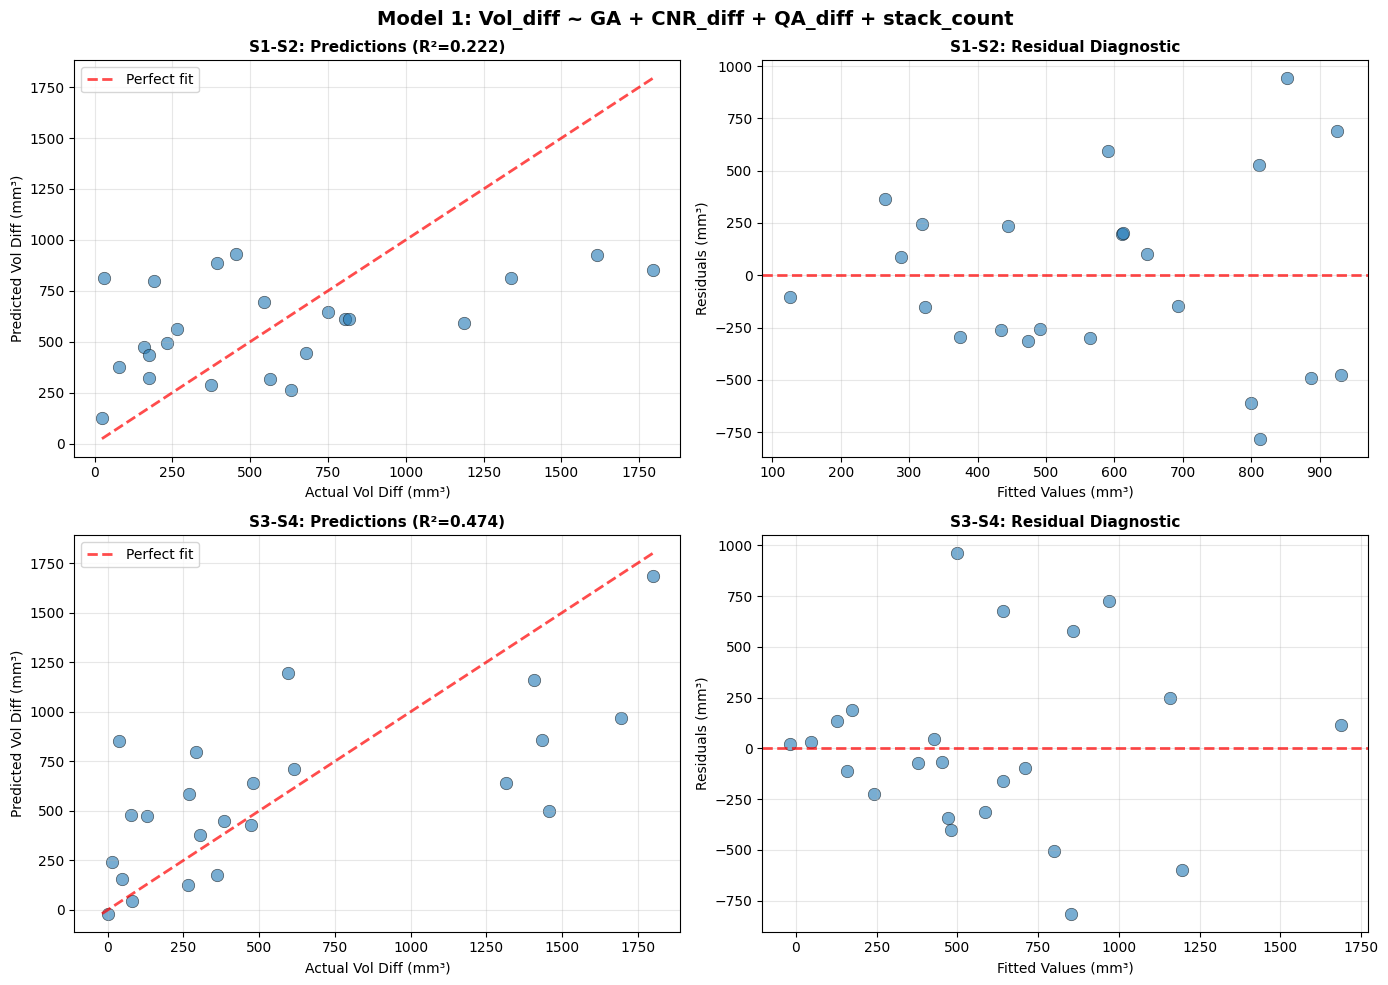

In [4]:
# Visualize Model 1
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model 1: Vol_diff ~ GA + CNR_diff + QA_diff + stack_count', fontsize=14, fontweight='bold')

for idx, (split, ax_row) in enumerate(zip(['S1-S2', 'S3-S4'], [axes[0], axes[1]])):
    result = results_m1[split]
    
    # Left: Actual vs Predicted
    ax = ax_row[0]
    ax.scatter(result['y'], result['y_pred'], s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
    min_val = min(result['y'].min(), result['y_pred'].min())
    max_val = max(result['y'].max(), result['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, alpha=0.7, label='Perfect fit')
    ax.set_xlabel('Actual Vol Diff (mm³)', fontsize=10)
    ax.set_ylabel('Predicted Vol Diff (mm³)', fontsize=10)
    ax.set_title(f'{split}: Predictions (R²={result["r2"]:.3f})', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Right: Residuals
    ax = ax_row[1]
    ax.scatter(result['y_pred'], result['residuals'], s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.axhline(y=0, color='r', linestyle='--', linewidth=2, alpha=0.7)
    ax.set_xlabel('Fitted Values (mm³)', fontsize=10)
    ax.set_ylabel('Residuals (mm³)', fontsize=10)
    ax.set_title(f'{split}: Residual Diagnostic', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model 2: Vol_diff ~ GA + CNR_diff + QA_mean + stack_count

In [5]:
results_m2 = {}
print('\nMODEL 2: Vol_diff ~ GA + CNR_diff + QA_mean + stack_count')
print('='*70)
for split_pair in ['S1-S2', 'S3-S4']:
    subset = data[data['split_pair'] == split_pair]
    result = fit_regression_model(subset, 'abs_diff_sp', ['GA', 'cnr_diff', 'QA_mean', 'stack_count'])
    if result:
        results_m2[split_pair] = result
        print(f"\n{split_pair}: N={result['n']}, R²={result['r2']:.3f}, F={result['f_stat']:.2f}, p={result['f_pvalue']:.4f}")
        for var, coef_data in result['coefs'].items():
            sig = '***' if coef_data['p'] < 0.001 else '**' if coef_data['p'] < 0.01 else '*' if coef_data['p'] < 0.05 else ''
            print(f"  {var:15s}: β={coef_data['coef']:10.4f}, SE={coef_data['se']:8.4f}, p={coef_data['p']:.4f} {sig}")


MODEL 2: Vol_diff ~ GA + CNR_diff + QA_mean + stack_count

S1-S2: N=23, R²=0.235, F=1.38, p=0.2807
  Intercept      : β=-1366.2365, SE=1300.8917, p=0.3075 
  GA             : β=   77.9445, SE= 39.9780, p=0.0670 
  cnr_diff       : β=75905.1915, SE=108504.8583, p=0.4931 
  QA_mean        : β= -619.0274, SE=790.1511, p=0.4436 
  stack_count    : β=    1.3840, SE= 42.0998, p=0.9741 

S3-S4: N=23, R²=0.408, F=3.11, p=0.0416
  Intercept      : β=-3709.8992, SE=1325.3215, p=0.0119 *
  GA             : β=  122.0877, SE= 42.9972, p=0.0109 *
  cnr_diff       : β=-5821.2451, SE=78418.8977, p=0.9416 
  QA_mean        : β= 1045.3653, SE=916.2560, p=0.2689 
  stack_count    : β=   21.9690, SE= 44.1682, p=0.6249 


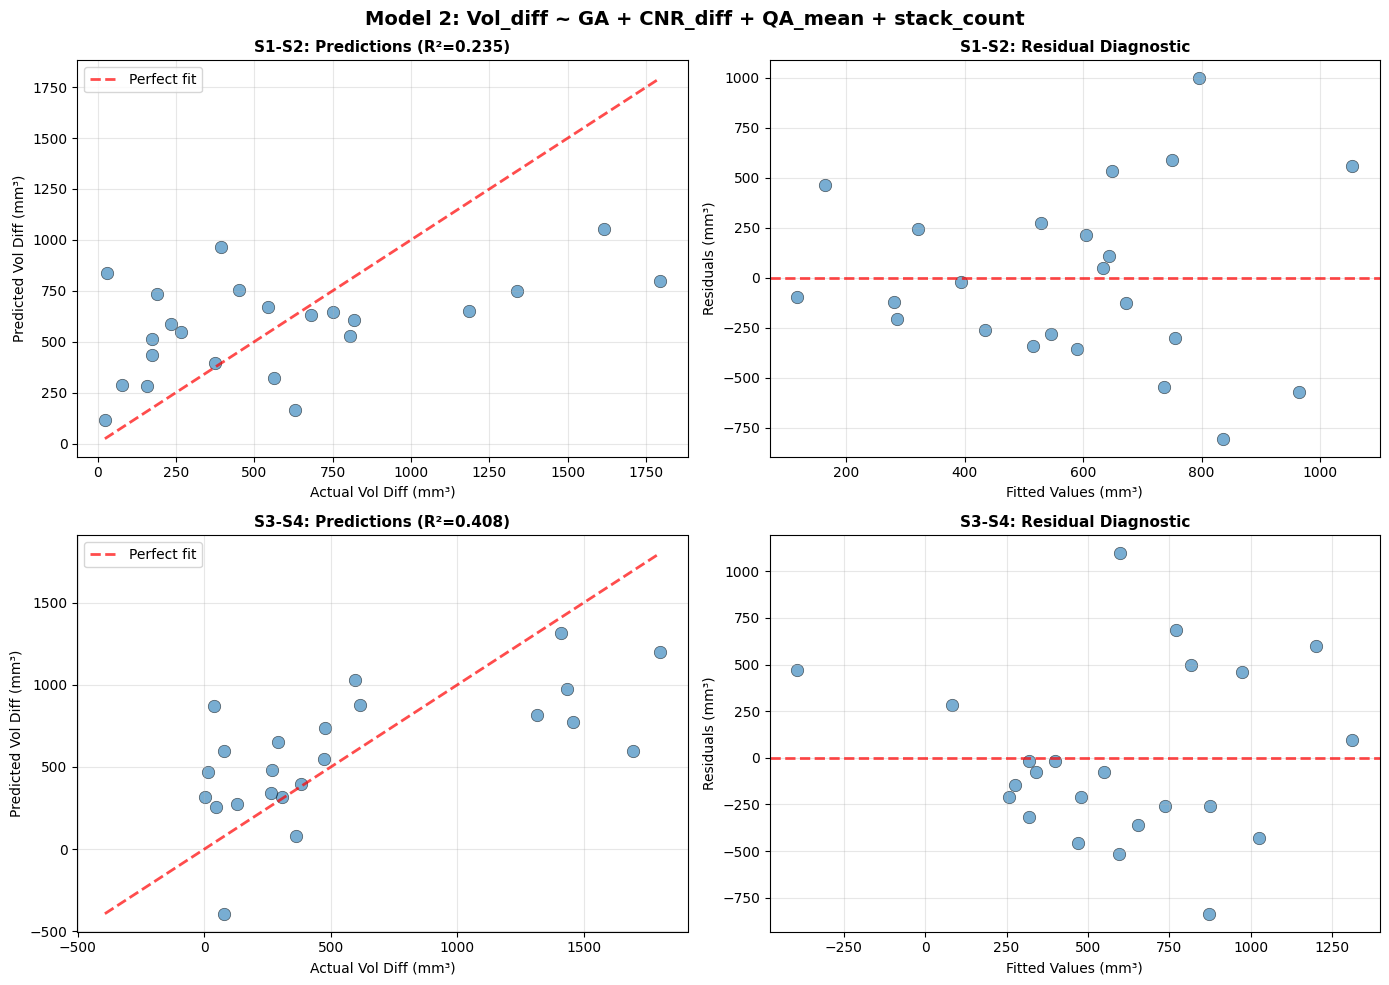

In [6]:
# Visualize Model 2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model 2: Vol_diff ~ GA + CNR_diff + QA_mean + stack_count', fontsize=14, fontweight='bold')

for idx, (split, ax_row) in enumerate(zip(['S1-S2', 'S3-S4'], [axes[0], axes[1]])):
    result = results_m2[split]
    
    # Left: Actual vs Predicted
    ax = ax_row[0]
    ax.scatter(result['y'], result['y_pred'], s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
    min_val = min(result['y'].min(), result['y_pred'].min())
    max_val = max(result['y'].max(), result['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, alpha=0.7, label='Perfect fit')
    ax.set_xlabel('Actual Vol Diff (mm³)', fontsize=10)
    ax.set_ylabel('Predicted Vol Diff (mm³)', fontsize=10)
    ax.set_title(f'{split}: Predictions (R²={result["r2"]:.3f})', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Right: Residuals
    ax = ax_row[1]
    ax.scatter(result['y_pred'], result['residuals'], s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.axhline(y=0, color='r', linestyle='--', linewidth=2, alpha=0.7)
    ax.set_xlabel('Fitted Values (mm³)', fontsize=10)
    ax.set_ylabel('Residuals (mm³)', fontsize=10)
    ax.set_title(f'{split}: Residual Diagnostic', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model 3: Vol_diff ~ GA + CNR_diff_resid + QA_diff + stack_count

In [7]:
def residualize(data, var_to_resid, var_ref):
    subset = data[[var_to_resid, var_ref]].dropna()
    X_ref = subset[[var_ref]]
    y_var = subset[var_to_resid]
    model = LinearRegression()
    model.fit(X_ref, y_var)
    residuals = y_var - model.predict(X_ref)
    res_series = pd.Series(index=subset.index, data=residuals.values)
    full_res = pd.Series(index=data.index, dtype=float)
    full_res[res_series.index] = res_series
    return full_res

results_m3 = {}
print('\nMODEL 3: Vol_diff ~ GA + CNR_diff_resid + QA_diff + stack_count')
print('(CNR_diff_resid = CNR_diff with GA component removed)')
print('='*70)

for split_pair in ['S1-S2', 'S3-S4']:
    data_resid = data[data['split_pair'] == split_pair].copy()
    data_resid['cnr_diff_resid'] = residualize(data_resid, 'cnr_diff', 'GA')
    
    result = fit_regression_model(data_resid, 'abs_diff_sp', ['GA', 'cnr_diff_resid', 'QA_diff', 'stack_count'])
    if result:
        results_m3[split_pair] = result
        print(f"\n{split_pair}: N={result['n']}, R²={result['r2']:.3f}, F={result['f_stat']:.2f}, p={result['f_pvalue']:.4f}")
        for var, coef_data in result['coefs'].items():
            sig = '***' if coef_data['p'] < 0.001 else '**' if coef_data['p'] < 0.01 else '*' if coef_data['p'] < 0.05 else ''
            print(f"  {var:15s}: β={coef_data['coef']:10.4f}, SE={coef_data['se']:8.4f}, p={coef_data['p']:.4f} {sig}")


MODEL 3: Vol_diff ~ GA + CNR_diff_resid + QA_diff + stack_count
(CNR_diff_resid = CNR_diff with GA component removed)

S1-S2: N=23, R²=0.222, F=1.28, p=0.3137
  Intercept      : β=-1699.1377, SE=1192.7286, p=0.1714 
  GA             : β=   78.2779, SE= 39.8845, p=0.0653 
  cnr_diff_resid : β=104926.5513, SE=99454.2100, p=0.3054 
  QA_diff        : β= -761.7340, SE=1370.3423, p=0.5851 
  stack_count    : β=   16.8525, SE= 35.7788, p=0.6433 

S3-S4: N=23, R²=0.474, F=4.05, p=0.0163
  Intercept      : β=-2781.3486, SE=1201.3704, p=0.0326 *
  GA             : β=  105.7940, SE= 41.6844, p=0.0206 *
  cnr_diff_resid : β=-18409.8356, SE=72958.7514, p=0.8036 
  QA_diff        : β= 2913.4588, SE=1515.6894, p=0.0706 
  stack_count    : β=   18.5179, SE= 37.6048, p=0.6284 


## Summary Table

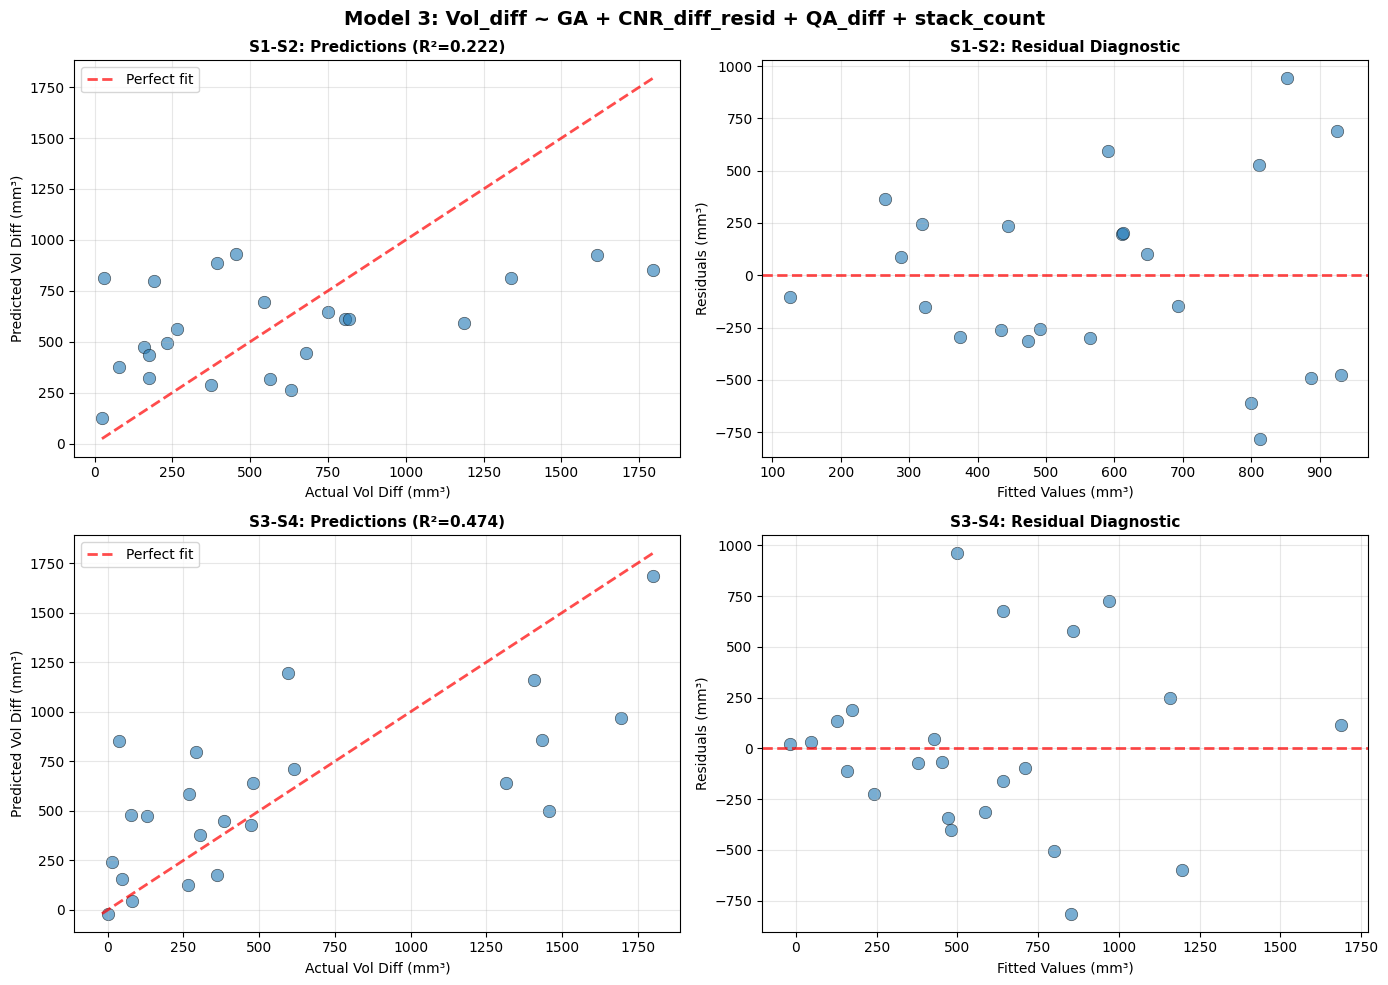

In [8]:
# Visualize Model 3
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model 3: Vol_diff ~ GA + CNR_diff_resid + QA_diff + stack_count', fontsize=14, fontweight='bold')

for idx, (split, ax_row) in enumerate(zip(['S1-S2', 'S3-S4'], [axes[0], axes[1]])):
    result = results_m3[split]
    
    # Left: Actual vs Predicted
    ax = ax_row[0]
    ax.scatter(result['y'], result['y_pred'], s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
    min_val = min(result['y'].min(), result['y_pred'].min())
    max_val = max(result['y'].max(), result['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, alpha=0.7, label='Perfect fit')
    ax.set_xlabel('Actual Vol Diff (mm³)', fontsize=10)
    ax.set_ylabel('Predicted Vol Diff (mm³)', fontsize=10)
    ax.set_title(f'{split}: Predictions (R²={result["r2"]:.3f})', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Right: Residuals
    ax = ax_row[1]
    ax.scatter(result['y_pred'], result['residuals'], s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.axhline(y=0, color='r', linestyle='--', linewidth=2, alpha=0.7)
    ax.set_xlabel('Fitted Values (mm³)', fontsize=10)
    ax.set_ylabel('Residuals (mm³)', fontsize=10)
    ax.set_title(f'{split}: Residual Diagnostic', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
summary_data = []
for model_num, results_dict in [(1, results_m1), (2, results_m2), (3, results_m3)]:
    for split, result in results_dict.items():
        summary_data.append({
            'Model': f'M{model_num}',
            'Split': split,
            'N': result['n'],
            'R²': round(result['r2'], 3),
            'Adj_R²': round(result['adj_r2'], 3),
            'F': round(result['f_stat'], 2),
            'p': round(result['f_pvalue'], 4)
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

Model Split  N    R²  Adj_R²    F      p
   M1 S1-S2 23 0.222   0.049 1.28 0.3137
   M1 S3-S4 23 0.474   0.357 4.05 0.0163
   M2 S1-S2 23 0.235   0.064 1.38 0.2807
   M2 S3-S4 23 0.408   0.277 3.11 0.0416
   M3 S1-S2 23 0.222   0.049 1.28 0.3137
   M3 S3-S4 23 0.474   0.357 4.05 0.0163


## Model Comparison Visualizations

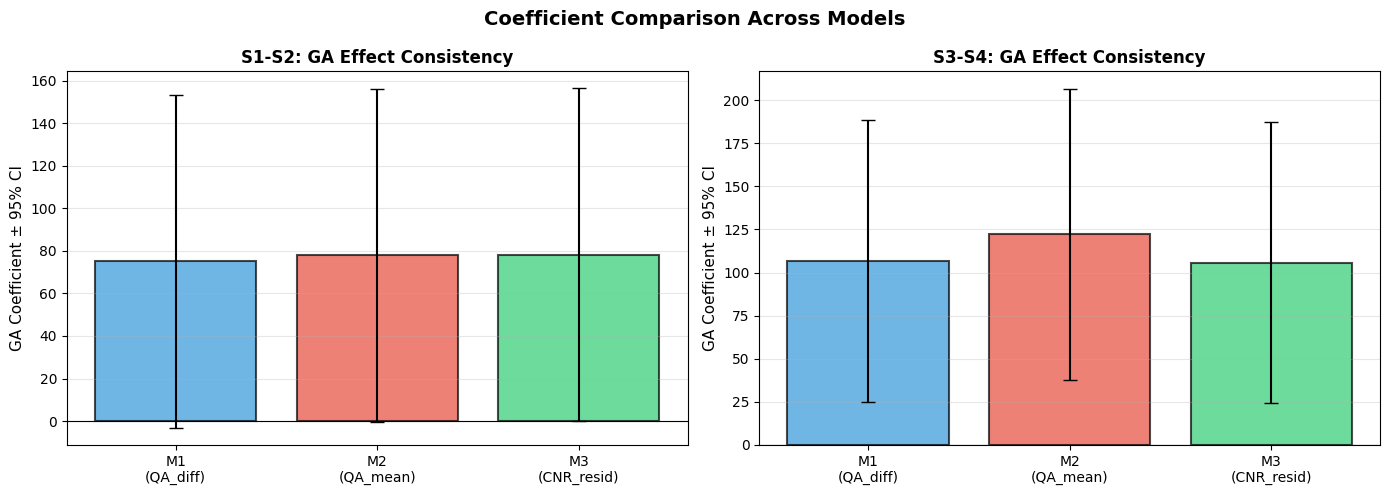

In [10]:
# Coefficient comparison across models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Coefficient Comparison Across Models', fontsize=14, fontweight='bold')

for split_idx, split in enumerate(['S1-S2', 'S3-S4']):
    ax = axes[split_idx]
    
    # Extract GA coefficients from each model
    models = ['M1\n(QA_diff)', 'M2\n(QA_mean)', 'M3\n(CNR_resid)']
    ga_coefs = []
    ga_sems = []
    
    for results_dict in [results_m1, results_m2, results_m3]:
        if split in results_dict:
            ga_coef = results_dict[split]['coefs']['GA']['coef']
            ga_se = results_dict[split]['coefs']['GA']['se']
            ga_coefs.append(ga_coef)
            ga_sems.append(1.96 * ga_se)
    
    x_pos = np.arange(len(models))
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    ax.bar(x_pos, ga_coefs, yerr=ga_sems, capsize=5, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, fontsize=10)
    ax.set_ylabel('GA Coefficient ± 95% CI', fontsize=11)
    ax.set_title(f'{split}: GA Effect Consistency', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()